In [ ]:
#This is an open-ended reliability investigation of automatic IOC restarts in CEBAF:

#Research question:

#Can temporal features help predict whether an automatic IOC restoration will fail?

#Descriptive analysis of when restarts/failures occur → reliability trends → supervised prediction of restoration failure.
#https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html

In [ ]:
#SELECTING DATA
import pandas as pd

df = pd.read_csv("slog_raw_data.csv")

df.tail(10)

,lognumber,title,body/format,body/content
1388,4471533,iocitfharp restored,html,<pre><b>restorelib 3.0.1\r\n\r\n</b>Target res...
1389,4471531,iocsoftw3spce restored,html,<pre><b>restorelib 3.0.1\r\n\r\n</b>Target res...
1390,4471530,iocsoftw3spce restored,html,<pre><b>restorelib 3.0.1\r\n\r\n</b>Target res...
1391,4471184,iocse15 restored,html,<pre><b>restorelib 3.0.1\r\n\r\n</b>Target res...
1392,4471182,ACG Report 02/16/2026,text,CED Updates for new Optics setup\r\nPockel and...
1393,4471128,iocitfharp restoration failed,html,<pre><b>restorelib 3.0.1\r\n\r\n</b>Target res...
1394,4471106,iocsl1 restored,html,<pre><b>restorelib 3.0.1\r\n\r\n</b>Target res...
1395,4471081,iocipmk101 restored,html,<pre><b>restorelib 3.0.1\r\n\r\n</b>Target res...
1396,4471030,iocsoftw3spce restored,html,<pre><b>restorelib 3.0.1\r\n\r\n</b>Target res...
1397,4470802,ACG Report 02/13/2026,text,Updated RF 2.0 and 3.0 Turn On Sequencers\r\nT...


In [ ]:
#FEATURE ENGINEERING

#Keep restoration entries
df = df[df["title"].str.contains("restored|restoration failed", case=False, na=False)].copy()

#extract date time from body/content
df["datetime"] = pd.to_datetime(
    df["body/content"].str.extract(
        r"Target restore date was.*?(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2})",
        expand=False
    ),
    errors="coerce"
)

# Split datetime into useful features
df["date"] = df["datetime"].dt.date
df["time"] = df["datetime"].dt.time
df["hour"] = df["datetime"].dt.hour
df["month"] = df["datetime"].dt.month
df["year"] = df["datetime"].dt.year


# Method to convert month into season
def get_season(month):
    if month in [12, 1, 2]:
      return "Winter"
    elif month in [3, 4, 5]:
      return "Spring"
    elif month in [6, 7, 8]:
      return "Summer"
    elif month in [9, 10, 11]:
      return "Fall"
    else:
      return None

df["season"] = df["month"].apply(get_season)

# Create True/False target
# True = restoration failed
# False = restoration worked
df["restoration_failed"] = df["title"].str.contains(
    "restoration failed",
    case=False,
    na=False
)

# Look at the engineered features
display(df[[
            "title",
            "datetime",
            "date",
            "time",
            "hour",
            "month",
            "season",
            "year",
            "restoration_failed"
        ]].tail()
)

,title,datetime,date,time,hour,month,season,year,restoration_failed
1391,iocse15 restored,2026-02-16 16:58:26,2026-02-16,16:58:26,16.0,2.0,Winter,2026.0,False
1393,iocitfharp restoration failed,2026-02-09 17:26:05,2026-02-09,17:26:05,17.0,2.0,Winter,2026.0,True
1394,iocsl1 restored,2026-02-16 11:13:41,2026-02-16,11:13:41,11.0,2.0,Winter,2026.0,False
1395,iocipmk101 restored,2026-02-16 09:06:47,2026-02-16,09:06:47,9.0,2.0,Winter,2026.0,False
1396,iocsoftw3spce restored,2026-02-15 15:21:36,2026-02-15,15:21:36,15.0,2.0,Winter,2026.0,False


In [ ]:
#CHECK NAN VALUES

display(df["datetime"].isna().sum())

#inspecting rows where the extraction failed:
df[df["datetime"].isna()][["title", "body/content"]]

# Mean/median imputation is inappropriate for missing timestamps because it
# invents event times and can distort temporal patterns in the data.

# Drop rows only when both date and time are missing
df = df.dropna(subset=["datetime"]).copy()

# Check that no missing datetimes remain
display(df["datetime"].isna().sum())



# Display the new column
display(

    df[["title", "date", "time", "restoration_failed"]].tail()

)

np.int64(19)

np.int64(0)

,title,date,time,restoration_failed
1391,iocse15 restored,2026-02-16,16:58:26,False
1393,iocitfharp restoration failed,2026-02-09,17:26:05,True
1394,iocsl1 restored,2026-02-16,11:13:41,False
1395,iocipmk101 restored,2026-02-16,09:06:47,False
1396,iocsoftw3spce restored,2026-02-15,15:21:36,False


In [ ]:
# EDA - Exploratory Data Analysis

# Before EDA, quicky checking overall successful vs failed restorations

display(df["restoration_failed"].value_counts())


# Create time-of-day categories - method
def get_time_of_day(hour):
    if 0 <= hour < 6:
        return "Night"
    elif 6 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 18:
        return "Afternoon"
    else:
        return "Evening"

df["time_of_day"] = df["hour"].apply(get_time_of_day)


# 1. Restorations and failure rate by time of day
display(
    df.groupby("time_of_day")["restoration_failed"]
      .agg(total_restorations="count",
           failures="sum",
           failure_rate="mean")
)


# 2. Restorations and failure rate by season
display(
    df.groupby("season")["restoration_failed"]
      .agg(total_restorations="count",
           failures="sum",
           failure_rate="mean")
)


# 3. Restorations and failure rate by year
display(
    df.groupby("year")["restoration_failed"]
      .agg(total_restorations="count",
           failures="sum",
           failure_rate="mean")
)

,count
restoration_failed,
False,1010
True,106


,total_restorations,failures,failure_rate
time_of_day,,,
Afternoon,340,26,0.076471
Evening,97,8,0.082474
Morning,601,64,0.106489
Night,78,8,0.102564


,total_restorations,failures,failure_rate
season,,,
Fall,10,6,0.600000
Spring,586,45,0.076792
Summer,450,36,0.080000
Winter,70,19,0.271429


,total_restorations,failures,failure_rate
year,,,
2025.0,20,11,0.550000
2026.0,1096,95,0.086679


# The results from EDA help answer:
**"Are automatic IOC restorations more likely to fail at certain times of day or during certain seasons?"**


* Time of day: Morning has the most restorations: 601, with 64 failures (10.6%). Afternoon is next with 340, but has a lower 7.6% failure rate.
* Season: Spring has the most restorations: 586, followed by Summer with 450. Their failure rates are very similar: 7.7% vs. 8.0%.
* Winter: Only 70 restorations, but a much higher 27.1% failure rate. This is worth investigating.
* Fall: 60% failure rate, but there are only 10 events, so there is not enough data to confidently say Fall is worse.
* Year: 2026 has 1,096 events versus only 20 in 2025, so you should not compare the years as evidence of improvement yet.

Most interesting finding so far: Winter appears to have a substantially higher failure rate, while morning is when the largest number of restoration events occurs.

**We found that failure rates change depending on the time of day and season based on historical data. So we can use time and season as features in our ML model to predict whether an IOC restoration will work or fail.**‼️️️️‼️️️️‼️️️️‼️️️️‼️️️️‼️️️️‼️️️️

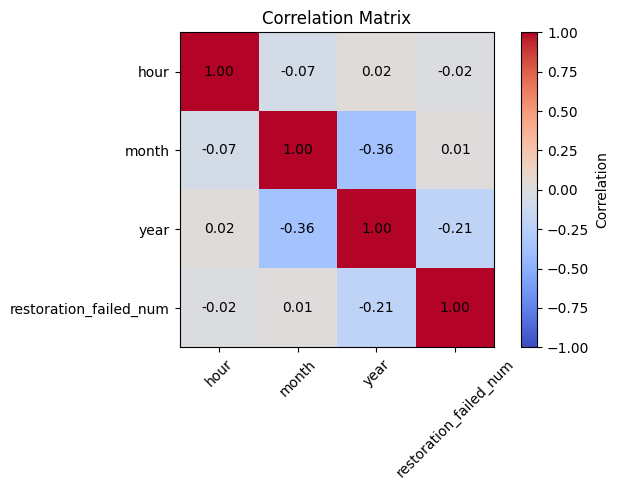

In [ ]:
# CORRELATION MATRIX

# Convert restoration failure from True/False to 1/0
df["restoration_failed_num"] = df["restoration_failed"].astype(int)

# Select numeric features for correlation
corr = df[
    ["hour", "month", "year", "restoration_failed_num"]
].corr()

#display(corr)


# PLOT CORRELATION MATRIX

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.imshow(
    corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

# Add correlation numbers inside each square
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        plt.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.colorbar(label="Correlation")
plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [ ]:
#Let's compare two models:

#Logistic Regression — our baseline. It’s easy to interpret and tells you whether features are associated with higher/lower failure probability.

#Random Forest Classifier — our main nonlinear model. It can capture interactions such as a particular IOC being especially unreliable during certain periods without requiring us to specify those relationships manually.

#Because we have 1,010 successes vs. only 106 failures, don’t judge the models primarily by accuracy. A model predicting "success" every time already gets ~90.5% accuracy.


LOGISTIC REGRESSION RESULTS
Accuracy: 0.8348214285714286
Precision: 0.16666666666666666
Recall: 0.19047619047619047
F1 Score: 0.17777777777777778
PR-AUC: 0.27056131674156575


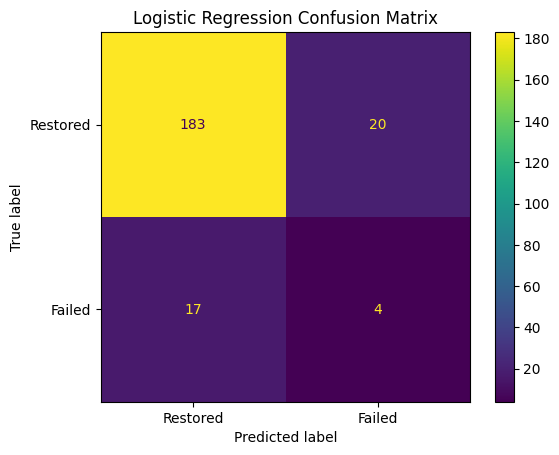

In [ ]:
# LOGISTIC REGRESSION
# Research Question:
# Can temporal features help predict whether an automatic IOC restoration will fail?

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    average_precision_score
)
import matplotlib.pyplot as plt


# 1. SELECT FEATURES AND TARGET

# Temporal features used to predict failure
X = df[
    [
        "hour",
        "month",
        "season",
        "time_of_day"
    ]
]

# Target:
# False = restoration worked
# True = restoration failed
y = df["restoration_failed"]


# 2. RANDOM TRAIN/TEST SPLIT

# 80% training data
# 20% testing data
# stratify keeps approximately the same percentage
# of failures in training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Check successful vs failed restorations in each set
#print("Training:")
#print(y_train.value_counts())

#print("\nTesting:")
#print(y_test.value_counts())


# 3. IDENTIFY NUMERIC AND CATEGORICAL FEATURES

numeric_features = [
    "hour",
    "month"
]

categorical_features = [
    "season",
    "time_of_day"
]


# 4. PREPARE FEATURES

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)


# 5. CREATE LOGISTIC REGRESSION MODEL

# class_weight="balanced" gives more importance
# to the less common failure cases

logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)


# 6. TRAIN MODEL

logistic_model.fit(
    X_train,
    y_train
)


# 7. MAKE PREDICTIONS

# Predict Restored or Failed
y_pred = logistic_model.predict(
    X_test
)

# Predict probability of failure
y_prob = logistic_model.predict_proba(
    X_test
)[:, 1]


# 8. EVALUATE MODEL

print("\nLOGISTIC REGRESSION RESULTS")

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

print(
    "Precision:",
    precision_score(
        y_test,
        y_pred,
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        y_pred,
        zero_division=0
    )
)

print(
    "F1 Score:",
    f1_score(
        y_test,
        y_pred,
        zero_division=0
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_test,
        y_prob
    )
)


# 9. CONFUSION MATRIX

cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Restored",
        "Failed"
    ]
)

disp.plot()

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()


RANDOM FOREST RESULTS
Accuracy: 0.6339285714285714
Precision: 0.16483516483516483
Recall: 0.7142857142857143
F1 Score: 0.26785714285714285
PR-AUC: 0.16783274378344015


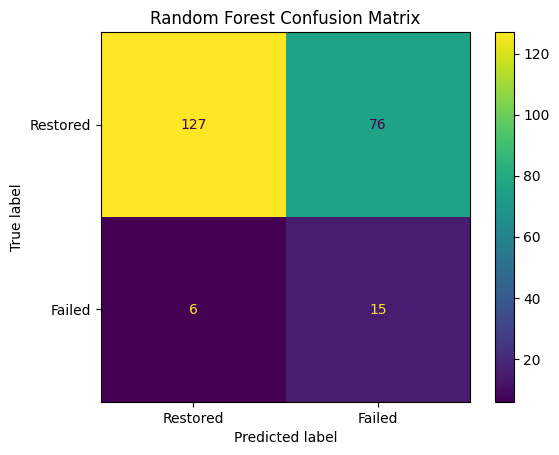

In [ ]:
# RANDOM FOREST CLASSIFIER
# Uses the EXACT SAME training and testing data as Logistic Regression

from sklearn.ensemble import RandomForestClassifier


# 1. PREPARE FEATURES FOR RANDOM FOREST

rf_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)


# 2. CREATE RANDOM FOREST MODEL

random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            rf_preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


# 3. TRAIN MODEL
# Same X_train and y_train as Logistic Regression

random_forest_model.fit(
    X_train,
    y_train
)


# 4. MAKE PREDICTIONS
# Same X_test as Logistic Regression

y_pred_rf = random_forest_model.predict(
    X_test
)

y_prob_rf = random_forest_model.predict_proba(
    X_test
)[:, 1]


# 5. EVALUATE RANDOM FOREST

print("\nRANDOM FOREST RESULTS")

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_rf)
)

print(
    "Precision:",
    precision_score(
        y_test,
        y_pred_rf,
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        y_pred_rf,
        zero_division=0
    )
)

print(
    "F1 Score:",
    f1_score(
        y_test,
        y_pred_rf,
        zero_division=0
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_test,
        y_prob_rf
    )
)


# 6. CONFUSION MATRIX

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=[
        "Restored",
        "Failed"
    ]
)

disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.show()